In [2]:
import pandas as pd
import csv
import matplotlib.pyplot as plt
import matplotlib_venn

Investigating the name fields of Care Inspectorate Scotland to allow for maximal number of matches to OSCR.

TO DO: Edit the matching algorithm to use the edit_names function on OSCR Names and CIS Service Provider names to find matches.

In [75]:

oscr_raw_df = pd.read_csv('/Users/fionack/Projects/TSO_project/raw_data/oscr_spine_public.csv')
oscr_spine_df = pd.read_csv('/Users/fionack/Projects/TSO_project/public_spine_data/oscr.spine.csv',usecols=['organisationname','id_in_source'])
oscr_spine_df.drop_duplicates()

cis_raw_df = pd.read_csv('/Users/fionack/Projects/TSO_project/raw_data/CareInspectScot.all.csv',encoding='Latin-1')
cis_spine_df = pd.read_csv('/Users/fionack/Projects/TSO_project/public_spine_data/CareInspectScot.spine.csv')



/var/folders/kx/my6qjd410pg_mks04z_5dm3r0000gn/T/ipykernel_65635/3029290418.py:1: DtypeWarning: Columns (14,22) have mixed types. Specify dtype option on import or set low_memory=False.
  oscr_raw_df = pd.read_csv('/Users/fionack/Projects/TSO_project/raw_data/oscr_spine_public.csv')
/var/folders/kx/my6qjd410pg_mks04z_5dm3r0000gn/T/ipykernel_65635/3029290418.py:5: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  cis_raw_df = pd.read_csv('/Users/fionack/Projects/TSO_project/raw_data/CareInspectScot.all.csv',encoding='Latin-1')


In [76]:
oscr_spine_df.columns

Index(['organisationname', 'id_in_source'], dtype='object')

In [77]:
cis_spine_df.columns

Index(['uid', 'organisationname', 'normalisedname', 'fulladdress', 'city',
       'postcode', 'companyid', 'registerdate', 'removeddate', 'source',
       'id_in_source'],
      dtype='object')

In [108]:
cis_raw_df.CSNumber

0         CS2003000133
1         CS2003000135
2         CS2003000137
3         CS2003000150
4         CS2003000152
              ...     
104585    CS2017354142
104586    CS2017354213
104587    CS2017354214
104588    CS2017354812
104589    CS2017354879
Name: CSNumber, Length: 104590, dtype: object

In [79]:
#capitalise all names - for matching

cis_raw_df['ServiceProvider'] = cis_raw_df['ServiceProvider'].str.upper()
cis_raw_df['ServiceName'] = cis_raw_df['ServiceName'].str.upper()
oscr_spine_df['organisationname'] = oscr_spine_df['organisationname'].str.upper()

cis_serviceproviders = set(cis_raw_df['ServiceProvider'])
cis_servicenames = set(cis_raw_df['ServiceName'])
oscr_orgs = set(oscr_spine_df['organisationname'])
print(f'OSCR has {len(oscr_orgs)} unique names')

print(f'CareInspectScot raw data has {len(cis_servicenames)} Service Names, and {len(cis_serviceproviders)} Service Provider names')


OSCR has 50191 unique names
CareInspectScot raw data has 18774 Service Names, and 11455 Service Provider names


Text(0.5, 1.0, 'CIS namefields intersections with OSCR primary name')

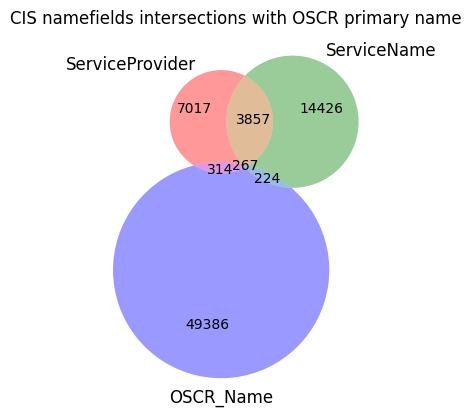

In [80]:

#namefields = ['ServiceProvider','ServiceName']
#
#cis_df=pd.read_csv('../..//public_spine_data/CareInspectScot.spine.tmp.csv',usecols=['uid','normalisedname','namefield'])
#oscr_names_df = pd.read_csv('../../public_spine_data/oscr.spine.csv', usecols=['normalisedname'])
#oscr_names = set(oscr_names_df['normalisedname'])
#cis_df['in_oscr'] = cis_df['normalisedname'].isin(oscr_names)
#cis_oscr_matches = cis_df[cis_df['in_oscr']==True]
#provider_name_matches = set(cis_oscr_matches[cis_oscr_matches['namefield']=='ServiceProvider']['uid'])
#service_name_matches = set(cis_oscr_matches[cis_oscr_matches['namefield']=='ServiceName']['uid'])

matplotlib_venn.venn3([cis_serviceproviders,cis_servicenames,oscr_orgs],('ServiceProvider','ServiceName','OSCR_Name'))
plt.title('CIS namefields intersections with OSCR primary name')



In [84]:
# normalise names (code from handler.base)
import string,re
def normalizer(name, norm_dict=None):
    ''' normalise entity names with manually curated dict'''
    norm_dict={}
    if isinstance(name, str):
        name = name.upper()
        for key, value in norm_dict.items():
            name = name.replace(key, value)
        name = name.replace(r"\(.*\)", " ")  # remove brackets
        name = name.replace(r"&", "AND")  
        name = name.replace(r"\+", "AND")  
        name = re.sub(r"(?<=\w)'(?=\w)", '', name)
        name = re.sub(r"(?<=\w)\.(?=\w)", '', name)
        for punct in string.punctuation:
            name = name.replace(punct, ' ')

        name = ' '.join(name.split()).strip()
        return name
    return None

cis_raw_df['ServiceProvider_norm'] = cis_raw_df['ServiceProvider'].apply(normalizer)
cis_raw_df['ServiceName_norm'] = cis_raw_df['ServiceName'].apply(normalizer)
oscr_spine_df['normalisedname'] = oscr_spine_df['organisationname'].apply(normalizer)

Text(0.5, 1.0, 'CIS namefields intersections with OSCR primary name (all names normalised)')

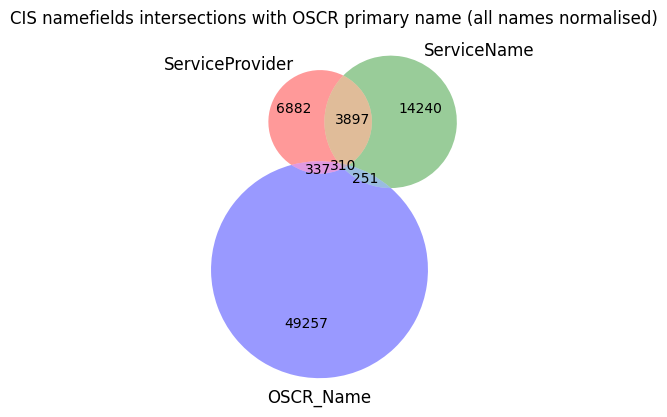

In [85]:
cis_serviceproviders_norm = set(cis_raw_df['ServiceProvider_norm'])
cis_servicenames_norm = set(cis_raw_df['ServiceName_norm'])
oscr_orgs_norm = set(oscr_spine_df['normalisedname'])

matplotlib_venn.venn3([cis_serviceproviders_norm,cis_servicenames_norm,oscr_orgs_norm],('ServiceProvider','ServiceName','OSCR_Name'))
plt.title('CIS namefields intersections with OSCR primary name (all names normalised)')



So normalising the names increases the match. Interested in whether some further text processing of the Service Provider names will increase the number of matches. 

In [210]:
def edit_names(name,use_break):
    if not isinstance(name, str):
        return ''
    for word in ['PARENTS COMMITTEE','THE COMMITTEE OF','COMMITTEE OF','MANAGEMENT COMMITTEE','COMMITTEE',\
                 'THE MANAGEMENT','MANAGEMENT','PARISH CHURCH',\
                 'AN ASSOCIATION','A SCOTTISH CHARITABLE INCORPORATED ASSOCIATION',\
                 'AN INCORPORATED ASSOCIATION','AN UNINCORPORATED ASSOCIATION','INCORPORATED ASSOCIATION',\
                 'A SCOTTISH CHARITABLE INCORPORATED ORGANISATION',\
                 'A COMPANY LIMITED BY GUARANTEE','OSC','ASC','SCOTTISH CHARITABLE INCORPORATED ORGANISATION',\
                 'A SCOTTISH CHARITABLE ORGANISATION', 'A SCIO', \
                 'AN SCIO', 'SCIO', 'BOARD OF GOVERNORS','LIMITED','LTD',\
                 'OUT OF SCHOOL CLUB','OUT OF SCHOOL CARE',\
                'AFTER SCHOOL CLUB','AFTER SCHOOL CARE SERVICE','DAY CARE',\
                 'PLAYGROUP','CLUB','THE']:
        if word in name:
            name = name.replace(word,'')
            if use_break:
                break
    return ' '.join(name.split()).strip()

Intersection of ServiceProvider (edited) with OSCR (edited) = 1032
Service Names but not Provider Names matching OSCR = 67


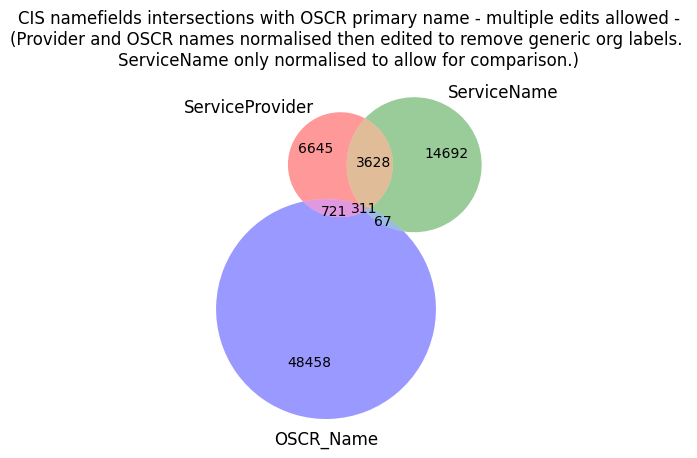

In [212]:



for usebreak in [False]:#,True]:
    cis_raw_df['ServiceProvider_edited'] = cis_raw_df['ServiceProvider_norm'].apply(edit_names,use_break = usebreak)
    cis_raw_df['ServiceName_edited'] = cis_raw_df['ServiceName_norm'].apply(edit_names,use_break = usebreak)
    oscr_spine_df['normalisedname_edited'] = oscr_spine_df['normalisedname'].apply(edit_names,use_break = usebreak)


    cis_serviceproviders_edited = set(cis_raw_df['ServiceProvider_edited'])
    cis_servicenames_edited = set(cis_raw_df['ServiceName_edited'])
    oscr_orgs_edited = set(oscr_spine_df['normalisedname_edited'])
    print(f'Intersection of ServiceProvider (edited) with OSCR (edited) = {len(oscr_orgs_edited.intersection(cis_serviceproviders_edited))}')
    print(f'Service Names but not Provider Names matching OSCR = {len(oscr_orgs_edited.intersection(cis_servicenames_norm)-cis_serviceproviders_edited)}')
    matplotlib_venn.venn3([cis_serviceproviders_edited,cis_servicenames_norm,oscr_orgs_edited],('ServiceProvider','ServiceName','OSCR_Name'))
    title = 'CIS namefields intersections with OSCR primary name '
    if usebreak:
        title += '- max one edit -'
    else:
        title += '- multiple edits allowed -'
    title += '\n(Provider and OSCR names normalised then edited to remove generic org labels. \nServiceName only normalised to allow for comparison.)'

    plt.title(title)
    plt.savefig(f'cis_venn_edit_{usebreak}.png')
    plt.show()


In [213]:
all_3_intersect = oscr_orgs_edited & cis_servicenames_norm & cis_serviceproviders_edited
servicename_not_providername_in_oscr = oscr_orgs_edited & cis_servicenames_edited - all_3_intersect


In [214]:
# for all in set servicename_not_providername_in_oscr: look at servicename and that row's providername:import pandas as pd
manual_check_no_match = ['CS2003015041'
'CS2011305163','CS2003001447',
'CS2003002584',
'CS2003001401',
'CS2010248424',
'CS2003001003',
'CS2003002644',
'CS2008177532',
'CS2008177877',
'CS2003003747',
'CS2003015041',
'CS2011305163',
'CS2003006940',
'CS2010272466',
'CS2006123979',
'CS2003004063',
'CS2012311130',
'CS2018365812',
'CS2012309817',
'CS2003009776',
'CS2003017047',
'CS2009195955',
'CS2004074029',
'CS200300144',
'CS2003005038',
'CS2003010328',
'CS2010278783',
'CS2003003746',
'CS2003002830',
'CS2015343823',
'CS2003008834',
'CS2013317609',
'CS2003003433',
'CS2008170184',
'CS2003010161',
'CS2003009683',
'CS2003034567',
'CS2003015416',
'CS2006134922',
'CS2008169806',
'CS2003009309',
'CS2007164002',
'CS2007150826',
'CS2004056921',
'CS2003001774',
'CS2005087507',
'CS2004066879',
'CS2003016168',
'CS2017362468',
'CS2003017956',
'CS2003016413',
'CS2004073845',
'CS2011303927',
'CS2003015627',
'CS2003005922',
'CS2011285812',
'CS2014333033',
'CS2018368569',
'CS2007142180',
'CS2003010639',
'CS2003035186',
'CS2003008531',
'CS2018365185',
'CS2011280879',
'CS2003000425',
'CS2003001134',]

lookup_values = []
for item in servicename_not_providername_in_oscr:
    if item in cis_raw_df['ServiceName_norm'].values:
        
        id = cis_raw_df.loc[cis_raw_df['ServiceName_norm'] == item, 'CSNumber'].values[0]
        if id in manual_check_no_match:
            continue
        value = cis_raw_df.loc[cis_raw_df['ServiceName_norm'] == item, 'ServiceProvider_edited'].values[0]
        value1 = oscr_spine_df.loc[oscr_spine_df['normalisedname_edited'] == item, 'normalisedname_edited'].values[0]
        value2 = oscr_spine_df.loc[oscr_spine_df['normalisedname_edited'] == value1, 'normalisedname'].values[0]
        lookup_values.append((id,item, value, value1, value2))

result_df = pd.DataFrame(lookup_values, columns=['cis_id','ServiceName_norm', 'ServiceProvider_edited', 'oscr_normalisedname_edited', 'oscr_normalisedname'])

print(result_df)


          cis_id  \
0   CS2003052080   
1   CS2021000370   
2   CS2014330552   
3   CS2008184593   
4   CS2003000295   
5   CS2003000306   
6   CS2003000161   
7   CS2003008626   
8   CS2019373484   
9   CS2017358457   
10  CS2003003598   
11  CS2017360575   
12  CS2015336888   
13  CS2003009589   
14  CS2003002617   
15  CS2007162742   
16  CS2004060561   
17  CS2003011554   
18  CS2004085396   

                                                ServiceName_norm  \
0                                                   STAR PROJECT   
1                                                           HAME   
2                                                  LITTLE ANGELS   
3                                          ROCKING HORSE NURSERY   
4                                                  SCOLTY CENTRE   
5                                                       FAITHLIE   
6                                             RICHMONDHILL HOUSE   
7                                                   WIL

In [203]:
def count_eq(df,fieldname):
    df['identical-names'] = df['ServiceName_norm'] == df[fieldname]
    print(f"Servicename == {fieldname} for {len(df[df['identical-names']==True])} names")
    return 

def not_eq(df,fieldname):
    df['identical-names'] = df['ServiceName_norm'] == df[fieldname]
    return df[df['identical-names']==False]

def count_both_edited(seriesA:pd.Series,seriesB:pd.Series):
    # matches between two series
    # check unique:
    def get_non_unique(s:pd.Series):
        a_df = s.value_counts()
        filtered_df = a_df[a_df > 1]
        non_unique = set(filtered_df.index)
        print(f'non unique values in series: {non_unique}')
        return non_unique
    
    non_uniqueA = get_non_unique(seriesA)
    non_uniqueB = get_non_unique(seriesB)

    print(f'{len(non_uniqueA)} nonunique names in seriesA')
    print(f'{len(non_uniqueB)} nonunique names in seriesB')
    
    a = {i for i in seriesA}
    b = {i for i in seriesB}
    matched = []
    for name in a - non_uniqueA:
        if name in b:
            if name in non_uniqueB:
                print(f'{name} matched but is not unique in OSCR')
            else:
                matched.append(name)
    print(f'{len(matched)} names matched for both sources edited')
    return matched

In [73]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 20)

def edit_names(name):
    for word in ['PARENTS COMMITTEE','THE COMMITTEE OF','COMMITTEE OF','MANAGEMENT COMMITTEE','COMMITTEE','AN ASSOCIATION',\
                 'A SCOTTISH CHARITABLE INCORPORATED ASSOCIATION','AN INCORPORATED ASSOCIATION','INCORPORATED ASSOCIATION',\
                 'A SCOTTISH CHARITABLE INCORPORATED ORGANISATION',\
                 'A COMPANY LIMITED BY GUARANTEE','OSC','ASC','SCOTTISH CHARITABLE INCORPORATED ORGANISATION','AN UNINCORPORATED ASSOCIATION',\
                    'A SCOTTISH CHARITABLE ORGANISATION', 'A SCIO','BOARD OF GOVERNORS','LIMITED','LTD']:
        if word in name:
            name = name.replace(word,'')
            break
    return name.strip()


result_df['newname'] = result_df['ServiceProvider_norm'].apply(edit_names)
oscr_spine_df['newname'] = oscr_spine_df['normalisedname'].apply(edit_names)
cis_raw_df['newname'] = cis_raw_df['ServiceProvider_norm'].apply(edit_names)
count_eq(result_df,'newname')
count_both_edited(cis_raw_df['newname'],oscr_spine_df['newname'])

n = not_eq(result_df,'newname')
not_eq_index = list(n.index)
print(f'Unmatched for {len(not_eq_index)} names')
for i in not_eq_index:
    ...#print(f"{n[n.index==i][['ServiceName_norm','ServiceProvider_norm']]}")



TypeError: argument of type 'NoneType' is not iterable

In [74]:
oscr_spine_df[oscr_spine_df['normalisedname']=='EKTA GROUP ELDERLY CARE FORUM']

,organisationname,id_in_source,organisationname_norm,normalisedname,newname
23773,EKTA GROUP ELDERLY CARE FORUM,SC025539,EKTA GROUP ELDERLY CARE FORUM,EKTA GROUP ELDERLY CARE FORUM,EKTA GROUP ELDERLY CARE FORUM
38221,EKTA GROUP- ELDERLY CARE FORUM,SC040007,EKTA GROUP ELDERLY CARE FORUM,EKTA GROUP ELDERLY CARE FORUM,EKTA GROUP ELDERLY CARE FORUM


In [23]:
print(result_df.loc[243])

ServiceName_norm                                                   GORDON DEMENTIA SERVICES SCIO
ServiceProvider_norm    GORDON DEMENTIA SERVICES A SCOTTISH CHARITABLE INCORPORATED ORGANISATION
newname                                                                 GORDON DEMENTIA SERVICES
identical-names                                                                            False
Name: 243, dtype: object


We should allow matches between provider name and oscr name when both have certain strings removed, e.g. ASC, SCIO.